# Notebook 2 — Feature Engineering & Social Prescription Recommendation (Age ≥ 65)

This notebook loads the baseline analytic dataset produced by Notebook 1 and builds:
1) an interpretable risk score,
2) a transparent rule-based recommendation engine (social prescription),
3) coverage checks (overall + subgroups).

**Input from Notebook 1**
- `../data_processed/notebook1_baseline_analytic.csv`

**Outputs from this notebook**
- `../data_processed/notebook2_recommendations.csv`
- `../data_processed/notebook2_coverage_report.csv`
- `../data_processed/notebook2_missingness_report.csv`
- plots for risk score distribution and recommendation coverage

In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)

DATA_DIR = "../data_processed"

INFILE = os.path.join(DATA_DIR, "notebook1_baseline_analytic.csv")

OUT_RECO = os.path.join(DATA_DIR, "notebook2_recommendations.csv")
OUT_COVERAGE = os.path.join(DATA_DIR, "notebook2_coverage_report.csv")
OUT_MISSINGNESS = os.path.join(DATA_DIR, "notebook2_missingness_report.csv")

print("CWD:", os.getcwd())
print("INFILE:", INFILE)
print("Exists:", os.path.exists(INFILE))

CWD: c:\Users\Yu\Desktop\BMI5111_Capstone_YuJun\notebooks
INFILE: ../data_processed\notebook1_baseline_analytic.csv
Exists: True


In [64]:
df = pd.read_csv(INFILE)
print("Loaded:", df.shape)
df.head()

Loaded: (29371, 10)


,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp,high_risk
0,2010,5,65.0,2.female,8.0,0.0,0,1.0,0.0,0
1,3010,11,76.0,1.male,12.0,0.0,0,0.0,1.0,0
2,3020,12,75.0,2.female,16.0,0.0,0,0.0,1.0,0
3,10001010,16,83.0,1.male,12.0,0.0,0,1.0,0.0,0
4,10003030,16,66.0,2.female,16.0,0.0,0,2.0,0.0,0


In [65]:
print(df.columns.tolist())
df.describe(include="all").T.head(20)

['hhidpn', 'wave', 'age', 'gender', 'edu_years', 'diabetes', 'adl_any', 'cesd', 'hosp', 'high_risk']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hhidpn,29371.0,NaN,NaN,NaN,223076403.25852,214891491.732567,2010.0,58515515.0,201890010.0,211351015.0,959738010.0
wave,29371.0,NaN,NaN,NaN,11.168908,4.68912,1.0,7.0,12.0,16.0,16.0
age,29371.0,NaN,NaN,NaN,78.388138,8.577403,65.0,71.0,78.0,85.0,109.0
gender,29371,2,2.female,16520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edu_years,29298.0,NaN,NaN,NaN,11.923135,3.555675,0.0,10.0,12.0,14.0,17.0
diabetes,29371.0,NaN,NaN,NaN,0.322495,0.598868,0.0,0.0,0.0,1.0,6.0
adl_any,29371.0,NaN,NaN,NaN,0.37234,0.483437,0.0,0.0,0.0,1.0,1.0
cesd,23887.0,NaN,NaN,NaN,1.766693,2.08101,0.0,0.0,1.0,3.0,8.0
hosp,29371.0,NaN,NaN,NaN,0.403357,0.49058,0.0,0.0,0.0,1.0,1.0
high_risk,29371.0,NaN,NaN,NaN,0.589868,0.491866,0.0,0.0,1.0,1.0,1.0


## 1) Basic cleaning / type fixes

We keep the dataset as-is (already baseline analytic from Notebook 1), and only do minimal safety conversions.

In [66]:
data = df.copy()

# Strip column names
data.columns = [c.strip() for c in data.columns]

# Convert obvious numeric columns to numeric when possible
for c in data.columns:
    if data[c].dtype == "object":
        # try numeric conversion; if too many become NaN, keep as object
        tmp = pd.to_numeric(data[c], errors="coerce")
        # if at least 70% convertible, replace
        if tmp.notna().mean() >= 0.7:
            data[c] = tmp

print(data.dtypes)
data.head()

hhidpn         int64
wave           int64
age          float64
gender           str
edu_years    float64
diabetes     float64
adl_any        int64
cesd         float64
hosp         float64
high_risk      int64
dtype: object


,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp,high_risk
0,2010,5,65.0,2.female,8.0,0.0,0,1.0,0.0,0
1,3010,11,76.0,1.male,12.0,0.0,0,0.0,1.0,0
2,3020,12,75.0,2.female,16.0,0.0,0,0.0,1.0,0
3,10001010,16,83.0,1.male,12.0,0.0,0,1.0,0.0,0
4,10003030,16,66.0,2.female,16.0,0.0,0,2.0,0.0,0


## 2) Identify key columns

Notebook 1 output seems to contain variables like:
- hosp, next_hosp, high_risk

We will:
- infer ID column (if exists)
- infer age column (if exists) and apply Age ≥ 65 filter if age is present
- build risk_score from available predictors (fallback strategy if some columns are missing)

In [67]:
def pick_first_existing_col(df, candidates, required=False):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of the candidate columns exist: {candidates}")
    return None

id_col = pick_first_existing_col(data, ["hhidpn", "HHIDPN", "id", "ID", "person_id"], required=False)
age_col = pick_first_existing_col(data, ["age", "AGE", "r_age", "baseline_age"], required=False)
sex_col = pick_first_existing_col(data, ["female", "sex", "SEX", "gender"], required=False)

print("id_col:", id_col)
print("age_col:", age_col)
print("sex_col:", sex_col)

# If age exists, enforce Age ≥ 65 (instructor requirement)
if age_col is not None:
    data[age_col] = pd.to_numeric(data[age_col], errors="coerce")
    before = data.shape[0]
    data = data[data[age_col] >= 65].copy()
    after = data.shape[0]
    print(f"Applied age>=65 filter: {before} -> {after}")
else:
    print("No age column found; skip age>=65 filter (dataset may already be restricted).")

data.head()

id_col: hhidpn
age_col: age
sex_col: gender
Applied age>=65 filter: 29371 -> 29371


,hhidpn,wave,age,gender,edu_years,diabetes,adl_any,cesd,hosp,high_risk
0,2010,5,65.0,2.female,8.0,0.0,0,1.0,0.0,0
1,3010,11,76.0,1.male,12.0,0.0,0,0.0,1.0,0
2,3020,12,75.0,2.female,16.0,0.0,0,0.0,1.0,0
3,10001010,16,83.0,1.male,12.0,0.0,0,1.0,0.0,0
4,10003030,16,66.0,2.female,16.0,0.0,0,2.0,0.0,0


## 3) Coverage report

We quantify missingness of each column (basic transparency).

In [68]:
coverage_df = pd.DataFrame({
    "column": data.columns,
    "missing_rate": [float(data[c].isna().mean()) for c in data.columns],
    "dtype": [str(data[c].dtype) for c in data.columns]
}).sort_values("missing_rate", ascending=False)

coverage_df.to_csv(OUT_MISSINGNESS, index=False)
coverage_df.head(30)

,column,missing_rate,dtype
7,cesd,0.186715,float64
4,edu_years,0.002485,float64
1,wave,0.000000,int64
0,hhidpn,0.000000,int64
3,gender,0.000000,str
2,age,0.000000,float64
5,diabetes,0.000000,float64
6,adl_any,0.000000,int64
8,hosp,0.000000,float64
9,high_risk,0.000000,int64


## 4) Risk score (interpretable, rule-based)

We construct a simple, transparent risk score using available baseline risk indicators.

Current components (if available in the dataset):

- Baseline hospital utilisation: `hosp ≥ 1`
- Elevated depressive symptoms proxy: `CESD ≥ 4` (RAND HRS 8-item scale)

Each component contributes 1 point.  
The final `risk_score` is the proportion of positive risk indicators (range 0–1).

This count-based approach is intentionally simple and interpretable, 
aligned with the project requirement for transparent, rule-based logic.

Note:
- The `high_risk` variable (if present) is inherited from Notebook 1 and is NOT redefined here.
- If `high_risk` is missing, a separate fallback flag may be generated, 
  but it does not overwrite the original definition.

In [69]:
import numpy as np
import pandas as pd

# ---------- Risk score (transparent count-based, auto-expand) ----------
risk_items = {}

def col_exists(c):
    return c in data.columns

def to_num(s, fill=None):
    x = pd.to_numeric(s, errors="coerce")
    if fill is not None:
        x = x.fillna(fill)
    return x

# 1) Prior hospital utilisation: hosp >= 1
if col_exists("hosp"):
    risk_items["hosp_ge1"] = (to_num(data["hosp"], fill=0) >= 1).astype(int)

# 2) Elevated depressive symptoms proxy: CESD >= 4
# (your column name is "cesd" in Notebook1 output)
if col_exists("cesd"):
    risk_items["cesd_ge4"] = (to_num(data["cesd"]) >= 4).astype(int)

# 3) Functional limitation: ADL any difficulty == 1
# (your Notebook1 mentioned "adl_any")
if col_exists("adl_any"):
    risk_items["adl_any_eq1"] = (to_num(data["adl_any"], fill=0) >= 1).astype(int)

# 4) Chronic condition: diabetes == 1
if col_exists("diabetes"):
    risk_items["diabetes_eq1"] = (to_num(data["diabetes"], fill=0) >= 1).astype(int)

# 5) Older age band: age >= 80 (optional but interpretable)
# use inferred age_col if you already detected it; otherwise try common names
age_candidate = None
for c in ["age", "AGE", "r_age", "baseline_age", "age_years"]:
    if c in data.columns:
        age_candidate = c
        break

if age_candidate is not None:
    risk_items["age_ge80"] = (to_num(data[age_candidate]) >= 80).astype(int)

# 6) Low education: edu_years <= 12 (optional socioeconomic vulnerability proxy)
# (your Notebook1 showed "edu_years")
if col_exists("edu_years"):
    edu = to_num(data["edu_years"])
    risk_items["edu_le12"] = ((edu.notna()) & (edu <= 12)).astype(int)

risk_df = pd.DataFrame(risk_items)

if risk_df.shape[1] == 0:
    data["risk_score"] = np.nan
    print("WARNING: No risk features available to compute risk_score.")
else:
    # proportion in [0,1], robust to missing columns
    data["risk_score"] = risk_df.sum(axis=1) / risk_df.shape[1]
    print("Risk features used:", list(risk_df.columns))
    print("risk_score summary:\n", data["risk_score"].describe())

    # Optional: show how many triggered per item (quick transparency)
    item_rates = risk_df.mean().sort_values(ascending=False)
    print("Risk item positive rates:\n", item_rates)

# ---------- High-risk flag (keep Notebook1 definition if present) ----------
if "high_risk" in data.columns:
    data["high_risk"] = pd.to_numeric(data["high_risk"], errors="coerce").fillna(0).astype(int)
    print("Using existing high_risk from Notebook 1 (cleaned to 0/1).")
else:
    if data["risk_score"].notna().any():
        thr = data["risk_score"].quantile(0.80)
        data["high_risk_fallback"] = (data["risk_score"] >= thr).astype(int)
        print(f"high_risk not found. Created high_risk_fallback using risk_score >= {thr:.3f} (top 20%).")
    else:
        data["high_risk_fallback"] = 0
        print("high_risk not found and risk_score unavailable. Created high_risk_fallback=0 for all.")

Risk features used: ['hosp_ge1', 'cesd_ge4', 'adl_any_eq1', 'diabetes_eq1', 'age_ge80', 'edu_le12']
risk_score summary:
 count    29371.000000
mean         0.380562
std          0.229951
min          0.000000
25%          0.166667
50%          0.333333
75%          0.500000
max          1.000000
Name: risk_score, dtype: float64
Risk item positive rates:
 edu_le12        0.612645
age_ge80        0.447448
hosp_ge1        0.403357
adl_any_eq1     0.372340
diabetes_eq1    0.292942
cesd_ge4        0.154642
dtype: float64
Using existing high_risk from Notebook 1 (cleaned to 0/1).


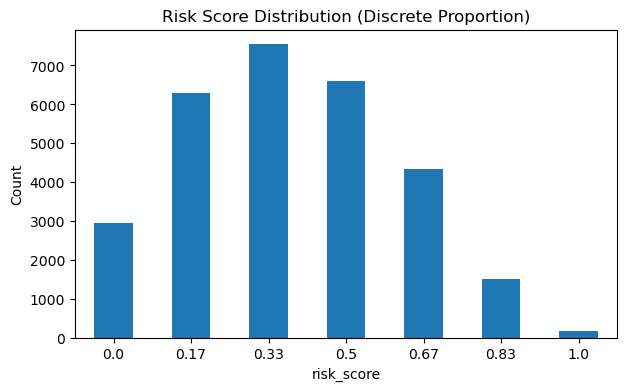

In [79]:
# Plot 1 — Risk score distribution (clean x-axis)

if "risk_score" in data.columns and data["risk_score"].notna().any():
    
    # Round to 2 decimal places for clean labels
    rounded_score = data["risk_score"].round(2)
    vc = rounded_score.value_counts().sort_index()

    plt.figure(figsize=(7,4))
    vc.plot(kind="bar")
    plt.title("Risk Score Distribution (Discrete Proportion)")
    plt.xlabel("risk_score")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

else:
    print("No valid risk_score available to plot.")

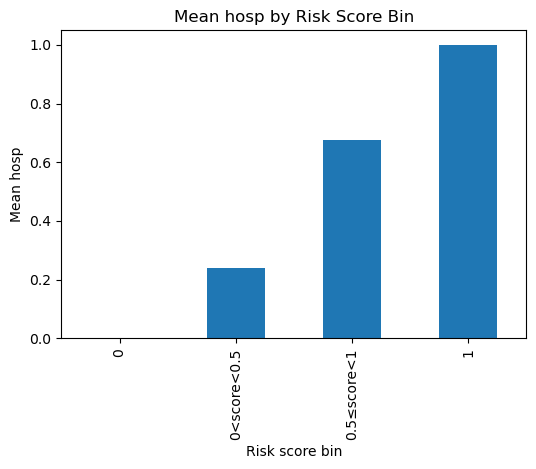

In [71]:
# Plot 2 — Outcome by risk level (sanity check)
outcome_col = None
for c in ["next_hosp", "hosp"]:
    if c in data.columns:
        outcome_col = c
        break

if outcome_col is None:
    print("No hosp/next_hosp column found for sanity check plot.")
else:
    tmp_out = pd.to_numeric(data[outcome_col], errors="coerce")
    tmp_risk = data["risk_score"] if "risk_score" in data.columns else None
    
    if tmp_risk is not None and tmp_risk.notna().any():
        # simple binning for interpretability
        bins = [-0.01, 0.01, 0.49, 0.99, 1.01]
        labels = ["0", "0<score<0.5", "0.5≤score<1", "1"]
        risk_bin = pd.cut(tmp_risk, bins=bins, labels=labels)
        
        plot_df = pd.DataFrame({"risk_bin": risk_bin, "outcome": tmp_out}).dropna()
        means = plot_df.groupby("risk_bin")["outcome"].mean()
        
        plt.figure(figsize=(6,4))
        means.plot(kind="bar")
        plt.title(f"Mean {outcome_col} by Risk Score Bin")
        plt.xlabel("Risk score bin")
        plt.ylabel(f"Mean {outcome_col}")
        plt.show()
    else:
        print("risk_score not available for sanity check plot.")

## 5) Recommendation engine (rule-based + reason codes)

We generate top-3 social prescription recommendations.
Rules adapt to available columns; if a signal is missing, that rule is skipped.

Output fields:
- top1, top2, top3
- reasons (joined)
- n_recs
- has_reco

## Service Catalogue (Rule-based Mapping)

This notebook outputs **service category recommendations** using **transparent, rule-based logic**.

| HRS Feature | Rule (threshold) | Need Domain | Service Category Recommended | Rationale |
|---|---|---|---|---|
| hosp | hosp ≥ 1 | care transitions | Care coordination / follow-up | Higher post-discharge needs & follow-up |
| cesd | CESD ≥ 4 | mental health | Mental health support | Elevated depressive symptoms proxy |
| high_risk (from Notebook 1) | high_risk == 1 | complex needs | Proactive outreach / case management | Higher complexity / multi-need |
| default | otherwise | general | General community resource information | Universal info; used to operationalise usual referral comparator |

**Comparator operationalisation:**  
We treat individuals who only receive **General community resource information** as **"usual referral / no social prescription"** (comparator group).  
Individuals who receive at least one **specific** service category are treated as **intervention-exposed**.

In [72]:
import pandas as pd

DEFAULT_SERVICE = "General community resource information"

RULES = [
    {
        "name": "Post-discharge / care transition needs",
        "priority": 1,
        "service": "Care coordination / follow-up",
        "cond": lambda r: ("hosp" in r and pd.notna(r["hosp"]) and float(r["hosp"]) >= 1),
    },
    {
        "name": "Elevated depressive symptoms (CESD proxy)",
        "priority": 2,
        "service": "Mental health support",
        "cond": lambda r: ("cesd" in r and pd.notna(r["cesd"]) and float(r["cesd"]) >= 4),
    },
    {
        "name": "High complexity / high-risk flag (from Notebook 1)",
        "priority": 3,
        "service": "Proactive outreach / case management",
        "cond": lambda r: ("high_risk" in r and pd.notna(r["high_risk"]) and int(r["high_risk"]) == 1),
    },
    {
        "name": "Functional limitation (ADL difficulty)",
        "priority": 2.5,
        "service": "Rehabilitation / functional support",
        "cond": lambda r: ("adl_any" in r and pd.notna(r["adl_any"]) and float(r["adl_any"]) >= 1),
    },
    {
        "name": "Chronic condition (diabetes)",
        "priority": 2.6,
        "service": "Chronic disease self-management support",
        "cond": lambda r: ("diabetes" in r and pd.notna(r["diabetes"]) and float(r["diabetes"]) >= 1),
    },
]

def recommend_row(row, topk=3):
    """
    Returns:
      services: list[str]  (sorted by priority)
      reasons:  list[str]  (human-readable rule names, aligned with services)
    """
    hits = []
    for rule in RULES:
        try:
            if rule["cond"](row):
                hits.append((rule["priority"], rule["service"], rule["name"]))
        except Exception:
            # Robust to unexpected row values
            continue

    hits.sort(key=lambda x: x[0])
    services = [h[1] for h in hits][:topk]
    reasons  = [h[2] for h in hits][:topk]

    if len(services) == 0:
        services = [DEFAULT_SERVICE]
        reasons  = ["Default / universal info (operationalises usual referral comparator)"]

    return services, reasons

# quick sanity print (so Cell 13 produces visible output)
print("Rules loaded:", len(RULES))
print("Default service:", DEFAULT_SERVICE)

Rules loaded: 5
Default service: General community resource information


In [73]:
import numpy as np
import pandas as pd

# Apply recommendation to each row
tmp = data.apply(lambda r: recommend_row(r, topk=3), axis=1)
data["reco_list"] = tmp.apply(lambda x: x[0])
data["reco_reason_list"] = tmp.apply(lambda x: x[1])

# Extract top1/top2/top3 (safe)
def get_k(lst, k):
    if isinstance(lst, list) and len(lst) > k:
        return lst[k]
    return None

data["top1"] = data["reco_list"].apply(lambda x: get_k(x, 0))
data["top2"] = data["reco_list"].apply(lambda x: get_k(x, 1))
data["top3"] = data["reco_list"].apply(lambda x: get_k(x, 2))

# Operationalise intervention vs comparator:
# - Only DEFAULT_SERVICE => comparator (usual referral / no social prescription)
# - Any specific service => intervention_exposed
data["has_specific_reco"] = (data["top1"] != DEFAULT_SERVICE).astype(int)
data["intervention_exposed"] = data["has_specific_reco"]
data["comparator_usual_referral"] = (1 - data["intervention_exposed"]).astype(int)

print("Any recommendation coverage:", float(data["top1"].notna().mean()))
print("Specific recommendation coverage (intervention_exposed=1):", float(data["intervention_exposed"].mean()))
print("Comparator coverage (usual referral):", float(data["comparator_usual_referral"].mean()))

# Quick preview
data[["top1","top2","top3","intervention_exposed","comparator_usual_referral"]].head(10)


Any recommendation coverage: 1.0
Specific recommendation coverage (intervention_exposed=1): 0.7038575465595315
Comparator coverage (usual referral): 0.29614245344046847


,top1,top2,top3,intervention_exposed,comparator_usual_referral
0,General community resource information,NaN,NaN,0,1
1,Care coordination / follow-up,NaN,NaN,1,0
2,Care coordination / follow-up,NaN,NaN,1,0
3,General community resource information,NaN,NaN,0,1
4,General community resource information,NaN,NaN,0,1
5,Care coordination / follow-up,NaN,NaN,1,0
6,General community resource information,NaN,NaN,0,1
7,Chronic disease self-management support,Proactive outreach / case management,NaN,1,0
8,Care coordination / follow-up,NaN,NaN,1,0
9,General community resource information,NaN,NaN,0,1


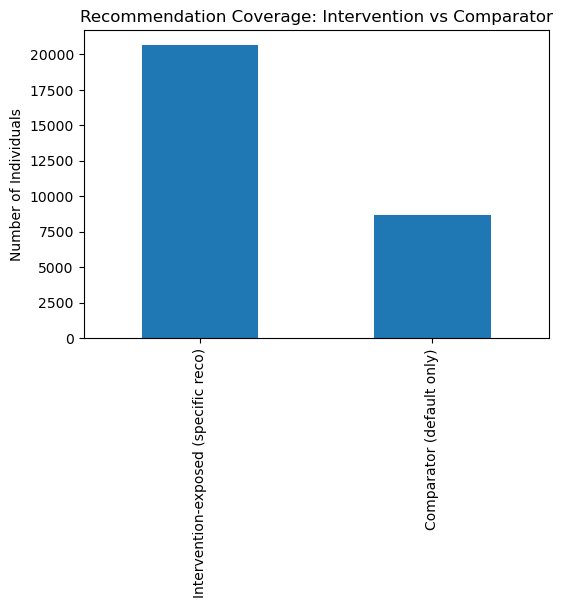

In [74]:
# Plot 3 — Recommendation coverage (intervention vs comparator)
if "intervention_exposed" in data.columns and "comparator_usual_referral" in data.columns:
    counts = pd.Series({
        "Intervention-exposed (specific reco)": int(data["intervention_exposed"].sum()),
        "Comparator (default only)": int(data["comparator_usual_referral"].sum()),
    })
    plt.figure(figsize=(6,4))
    counts.plot(kind="bar")
    plt.title("Recommendation Coverage: Intervention vs Comparator")
    plt.ylabel("Number of Individuals")
    plt.xlabel("")
    plt.show()
else:
    print("Coverage flags not found for plotting.")

## 6) Coverage checks (overall + subgroup)

We report:
- overall % with at least 1 recommendation (any coverage)
- overall % with at least 1 **specific** recommendation (intervention exposure)
- subgroup coverage by sex (if available) and by age bands (if age exists)


In [75]:
import pandas as pd
import numpy as np

def pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

gender_col = pick_col(data, ["gender", "sex", "ragender", "rsex"])
age_col    = pick_col(data, ["age", "r_agey", "agey", "raagey", "age_years"])

overall_any = float(data["top1"].notna().mean())
overall_specific = float(data["intervention_exposed"].mean())

print(f"Overall coverage (any recommendation): {overall_any:.3f}")
print(f"Overall coverage (specific / intervention_exposed): {overall_specific:.3f}")

coverage_rows = []
coverage_rows.append({
    "group": "ALL",
    "group_value": "ALL",
    "n": int(len(data)),
    "any_coverage": overall_any,
    "specific_coverage": overall_specific
})

if gender_col is not None:
    g = data.groupby(gender_col, dropna=False).agg(
        n=("top1", "size"),
        any_coverage=("top1", lambda s: float(s.notna().mean())),
        specific_coverage=("intervention_exposed", "mean"),
    ).reset_index().rename(columns={gender_col: "group_value"})
    g.insert(0, "group", "sex")
    coverage_rows += g.to_dict("records")

if age_col is not None:
    age_vals = pd.to_numeric(data[age_col], errors="coerce")
    age_band = pd.cut(age_vals, bins=[-np.inf, 49, 64, 74, 84, np.inf],
                      labels=["<=49","50-64","65-74","75-84","85+"])
    tmp_df = data.copy()
    tmp_df["_age_band"] = age_band

    a = tmp_df.groupby("_age_band", dropna=False).agg(
        n=("top1", "size"),
        any_coverage=("top1", lambda s: float(s.notna().mean())),
        specific_coverage=("intervention_exposed", "mean"),
    ).reset_index().rename(columns={"_age_band": "group_value"})
    a.insert(0, "group", "age_band")
    coverage_rows += a.to_dict("records")

coverage_report = pd.DataFrame(coverage_rows)
coverage_report


Overall coverage (any recommendation): 1.000
Overall coverage (specific / intervention_exposed): 0.704


,group,group_value,n,any_coverage,specific_coverage
0,ALL,ALL,29371,1.0,0.703858
1,sex,1.male,12851,1.0,0.692864
2,sex,2.female,16520,1.0,0.712409
3,age_band,65-74,10994,1.0,0.619884
4,age_band,75-84,10698,1.0,0.723219
5,age_band,85+,7679,1.0,0.797109


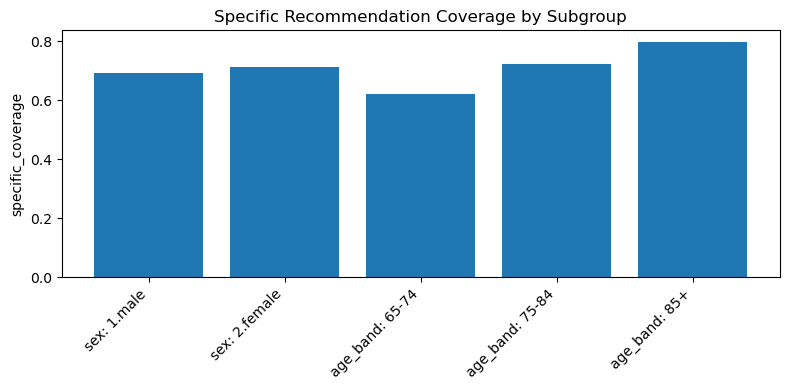

In [76]:
# Optional — subgroup specific coverage plot (if available)
if "group" in coverage_report.columns and "specific_coverage" in coverage_report.columns:
    sub = coverage_report[coverage_report["group"] != "ALL"].copy()
    if len(sub) > 0:
        labels = sub["group"].astype(str) + ": " + sub["group_value"].astype(str)
        plt.figure(figsize=(8,4))
        plt.bar(labels, sub["specific_coverage"])
        plt.title("Specific Recommendation Coverage by Subgroup")
        plt.ylabel("specific_coverage")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

## 7) Save outputs

We save the recommendation outputs and coverage report for downstream evaluation.


In [77]:
import os

# Save recommendations (with reason codes + intervention/comparator flags)
reco_cols = [c for c in [
    "risk_score",
    "high_risk" if "high_risk" in data.columns else None,
    "high_risk_fallback" if "high_risk_fallback" in data.columns else None,
    "top1","top2","top3",
    "reco_list","reco_reason_list",
    "has_specific_reco","intervention_exposed","comparator_usual_referral"
] if c is not None and c in data.columns]

# Recommendations file
data[reco_cols].to_csv(OUT_RECO, index=False)

# Coverage report file (do NOT overwrite missingness report)
coverage_report.to_csv(OUT_COVERAGE, index=False)

print("Saved recommendations to:", OUT_RECO)
print("Saved coverage report to:", OUT_COVERAGE)
print("Saved missingness report to:", OUT_MISSINGNESS)


Saved recommendations to: ../data_processed\notebook2_recommendations.csv
Saved coverage report to: ../data_processed\notebook2_coverage_report.csv
Saved missingness report to: ../data_processed\notebook2_missingness_report.csv
